# 数据科学/数据处理的通用框架流程

文件来源： 此文件出自Python For Beginner学习社群。

作者： 闫小峰

Last Update: 2025-07-08

## 数据处理通用框架/流程模板

[0. 业务理解 Understanding](#0) 

[1. 数据获取和理解 ](#1)
- 数据分析环境设置 Set Up Environment
- 数据获取/采样
- 数据探索  
  - 熟悉数据属性
  - 数据体检： Sanity Checking 

[2. 预处理 Data Preparation](#2)  
- 数据清理  Data Cleaning 
- 数据准备，转换和调整


[3. 数据分析和挖掘 Data Analysis / Data  Mining](#3)
- 传统（经典）数据分析： 
  - 统计学方法 
  - 建模： 业务分析模型
- 机器学习 Machine Learning: 
  - 模型构建: 训练-测试-调试， 
  - 模型预测
- AI增强/辅助型数据分析和开发
  - LLM

[4. 模型评估  Model Evaluation ](#4)


[5. 业务理解/知识深化和提升](#5)
- 数据处理流程自动化 Pipelines
- X by Data Based/Data Driven
   -  Decision Making
   -  Story Line
   -  逻辑论证
   -  发现规律 etc

# 0.业务理解Understanding

- 目标和需求分析：
  - 数据分析的背景，动机和目的：数据分析的背景，动机和目的： 
  - 目的：
    - 岗位基本操作训练：学习+练习numpy基础结构和操作
    - 跟练数据分析全栈流程框架
    - 本项目是Python数据科学学习的第二个基于Numpy为主要数据处理库的项目。设计为房地产数据分析。
- 操作执行战术分析：
  - 阶段性要求：
    - 收集德国地区或全德国的房地产数据，拆分为区域性np.array数组类型数据进行分析和建模
      - 数据来源： ImmoScout24, Kaggle dataset
    - 掌握掌握np.array基本认知和管理： 整体查询 + 创建 + 索引/切片+ 更改 + 排序
    - 可以执行初步数据运算和分析
    - 数据可视化（重点介绍matplotlib面向对象API的认知框架 + 画图步骤 +创建高级图形）
  - 数据分析需要的方法
    - 总结练习心得
  - 重点练习：数据分析流程全栈，使用matplotlib以及其他第三方图像库深化可视化数据的能力
- 操作执行战术分析：数据分析需要的方法

### 1. 数据获取和理解 Get Data & Data Understanding <a id="1"></a>

### 1.1. 数据处理环境设置 Set Up Environment <a id="1.1"></a>

In [4]:
# import modules for data science 
import numpy as np
import pandas as pd

#import module for plotting
import matplotlib.pyplot as plt 
#import rcParams um chinesische Texte richtig in Matplotlib anzuzeigen
from matplotlib import rcParams
# Setze die chin. Schriftart für den Titel, die in Matpolotlib angezeigt werden kann
rcParams['font.family'] = 'SimHei'  # oder 'Microsoft YaHei'

import warnings
warnings.filterwarnings('ignore') #to suppress warning messages


import pybds_lib as pds

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1.2. 数据获取

导入德国房地产数据。
（来源：kaggle, 数据是从immoscout24爬下来的）

原数据集经过作者预处理，筛选出最有价值的数据信息，并以Python字典格式存在本地目录data下。 需预先导入才能进行分析

In [5]:
# load  a numpy file to workspace 
loaded_arrays=np.load('data/immo_data_dict.npy', allow_pickle=True).item()

### GPT： 代码分析（Breakdown of the Code）

    np.load('data/immo_data_dict.npy', allow_pickle=True):
        This part of the code uses the np.load() function to load the contents of the specified .npy file.
        The allow_pickle=True argument allows the loading of pickled objects. This is important if the saved data contains Python objects (like dictionaries, lists, or custom objects) that were serialized using Python's pickle module.
        If the file contains only standard NumPy arrays (with numeric or string data types), you could set allow_pickle=False, but if you're unsure or if the data contains complex objects, it's safer to keep it as True.

    .item():
        After loading the data, the .item() method is called on the loaded object.
        This method is used to extract a single element from a NumPy array that contains only one element. If the loaded data is a single-element array, item() will return that element as a standard Python scalar (like an int, float, or dict).
        If the loaded data is a dictionary (which is common when using pickle), calling .item() will not be necessary, as dictionaries are already a native Python type. However, if the loaded data is a single-element NumPy array, item() will convert it to a scalar.


## 数据探索  
  - 熟悉数据属性
  - 数据体检： Sanity Checking

In [6]:
loaded_arrays.keys()

dict_keys(['date', 'regio1', 'regio3', 'geo_krs', 'geo_plz', 'totalrent', 'baserent', 'room_no', 'floor', 'liv_space', 'year_built'])

In [7]:
# extract the data from the dictionary
date = loaded_arrays['date']
regio1 = loaded_arrays['regio1']
regio3 = loaded_arrays['regio3']
totalrent = loaded_arrays['totalrent']
baserent = loaded_arrays['baserent']
room_no = loaded_arrays['room_no']
floor = loaded_arrays['floor']
liv_space = loaded_arrays['liv_space']
geo_krs = loaded_arrays['geo_krs']
geo_plz = loaded_arrays['geo_plz']
geo_plz = geo_plz.astype(str)  # convert to string for consistency
year_built = loaded_arrays['year_built']

In [8]:
# find in array geo_plz all plz start with "71"
geo_plz_start_71 = geo_plz[np.char.startswith(geo_plz,'71')] 
geo_plz_start_71

array(['71522', '71229', '71334', '71032', '71394', '71394', '71384',
       '71287', '71640', '71229', '71063', '71126', '71034', '71272',
       '71665', '71088', '71034', '71272', '71032', '71729', '71263',
       '71116', '71686', '71083', '71263', '71034', '71034', '71636',
       '71573', '71735', '71634', '71144', '71334', '71364', '71735',
       '71032', '71120', '71032', '71229', '71034', '71726', '71263',
       '71120', '71032', '71034', '71083', '71397', '71272', '71034',
       '71063', '71543', '71229', '71717', '71229', '71701', '71686',
       '71642', '71737', '71229', '71384', '71069', '71272', '71116',
       '71332', '71063', '71254', '71116', '71254', '71696', '71636',
       '71034', '71364', '71299', '71686', '71063', '71522', '71706',
       '71272', '71636', '71696', '71640', '71732', '71696', '71149',
       '71364', '71287', '71034', '71332', '71254', '71034', '71093',
       '71364', '71065', '71701', '71149', '71067', '71065', '71144',
       '71292', '712

In [9]:
year_built[:10]

array([1918.,   nan, 1997., 2011.,   nan, 1965., 1930., 1963., 1985.,
       1900.])

In [10]:
loaded_arrays.values()

dict_values([array(['May19', 'May19', 'Sep18', ..., 'May19', 'Sep18', 'Sep18'],
      shape=(198379,), dtype=object), array(['Nordrhein_Westfalen', 'Sachsen', 'Nordrhein_Westfalen', ...,
       'Sachsen', 'Niedersachsen', 'Sachsen'],
      shape=(198379,), dtype=object), array(['Karnap', 'Werdau', 'Emsdetten', ..., 'Borna', 'Garbsen',
       'Eilenburg'], shape=(198379,), dtype=object), array(['Essen', 'Zwickau_Kreis', 'Steinfurt_Kreis', ..., 'Leipzig_Kreis',
       'Hannover_Kreis', 'Nordsachsen_Kreis'],
      shape=(198379,), dtype=object), array(['45329', '08412', '48282', ..., '04552', '30827', '04838'],
      shape=(198379,), dtype=object), array([429.  ,    nan, 578.  , ..., 449.  , 795.82, 700.  ],
      shape=(198379,)), array([329.  , 169.  , 459.  , ..., 329.  , 578.82, 500.  ],
      shape=(198379,)), array([2., 2., 3., ..., 2., 3., 4.], shape=(198379,)), array([ 0., nan,  2., ...,  2.,  2.,  1.], shape=(198379,)), array([ 52.21,  44.  ,  75.  , ...,  56.  ,  76.16, 100.  ],

## 2. 数据预处理 Data Preparation  <a id="2"></a>

- 数据清理  Data Cleaning 
- 数据准备，转换和调整

In [11]:
baserent_summary = pds.describe_array(baserent)
#isinstance(baserent, np.ndarray)
print("Array statistical overview: \n")
for key, value in baserent_summary.items():
    print(f"{key}:  {value}")

Array statistical overview: 

Size:  198379
dtype:  float64
Shape:  (198379,)
Memory_usage:  1587032
NaN_count:  0
finite_count:  198379
Mean:  653.1439146784691
Median:  480.02
Min:  0.0
Max:  1234567.0
Range:  1234567.0
Std:  3612.9755261861856
Var:  13053592.152820343
Skewness:  307.6785959002435
Kurtosis:  98089.85470724627


In [12]:
livsp_summary = pds.describe_array(liv_space)
#isinstance(baserent, np.ndarray)
print("Array statistical overview: \n")
for key, value in livsp_summary.items():
    print(f"{key}:  {value}")

Array statistical overview: 

Size:  198379
dtype:  float64
Shape:  (198379,)
Memory_usage:  1587032
NaN_count:  0
finite_count:  198379
Mean:  74.88601898386422
Median:  67.5
Min:  0.0
Max:  111111.0
Range:  111111.0
Std:  295.935711920264
Var:  87577.94558975348
Skewness:  323.2082062235919
Kurtosis:  112428.70898770615


In [13]:
year_summary = pds.describe_array(year_built)
#isinstance(baserent, np.ndarray)
print("Array statistical overview: \n")
for key, value in year_summary.items():
    print(f"{key}:  {value}")

Array statistical overview: 

Size:  198379
dtype:  float64
Shape:  (198379,)
Memory_usage:  1587032
NaN_count:  42302
finite_count:  156077
Mean:  1966.2428801168653
Median:  1972.0
Min:  1000.0
Max:  2090.0
Range:  1090.0
Std:  43.99996118613764
Var:  1935.9965843816185
Skewness:  -2.846061296495588
Kurtosis:  35.45318833783336


In [14]:
totalrent_summary = pds.describe_array(totalrent)
#isinstance(baserent, np.ndarray)
print("Array statistical overview: \n")
for key, value in totalrent_summary.items():
    print(f"{key}:  {value}")

Array statistical overview: 

Size:  198379
dtype:  float64
Shape:  (198379,)
Memory_usage:  1587032
NaN_count:  29770
finite_count:  168609
Mean:  917.304971264879
Median:  640.0
Min:  0.0
Max:  15751535.0
Range:  15751535.0
Std:  38575.38593230619
Var:  1488060399.8263664
Skewness:  404.02967137793706
Kurtosis:  164851.25303594253


In [15]:
room_summary = pds.describe_array(room_no)
#isinstance(baserent, np.ndarray)
print("Array statistical overview: \n")
for key, value in room_summary.items():
    print(f"{key}:  {value}")

Array statistical overview: 

Size:  198379
dtype:  float64
Shape:  (198379,)
Memory_usage:  1587032
NaN_count:  0
finite_count:  198379
Mean:  2.653179267966871
Median:  3.0
Min:  1.0
Max:  999.99
Range:  998.99
Std:  3.0147837016945567
Var:  9.088920768003133
Skewness:  226.6150101945122
Kurtosis:  67238.61974689028


In [16]:
floor_summary = pds.describe_array(floor)
#isinstance(baserent, np.ndarray)
print("Array statistical overview: \n")
for key, value in floor_summary.items():
    print(f"{key}:  {value}")

Array statistical overview: 

Size:  198379
dtype:  float64
Shape:  (198379,)
Memory_usage:  1587032
NaN_count:  37621
finite_count:  160758
Mean:  2.1272596076089525
Median:  2.0
Min:  -1.0
Max:  999.0
Range:  1000.0
Std:  4.013973746595186
Var:  16.11198523835539
Skewness:  154.57121481092366
Kurtosis:  32572.390764808242


### 数据探索的初步印象和结论

问题多多，其种类有：
1. 缺失值Nan不均匀的存在于多个数组中
2. 所有数组最大最小值都不合理

只有Median中值看似比较现实

## 数据Data Cleaning

挑战：复杂数据群中搜寻数值中的缺失值和0，因为数据分析需要使用Numpy的数学运算（特别是有除法运算时），找到任意一个后删除所有数组的该行

疑问：
1. 如何找？ loaded_arrays包含了混合数据类型的Numpy数组，如str, int，float values，如何使用Numpy指令来查询Nan和0? 
2. 找到后如何删？ 目标：保持所有数组具有相同数据长度

解决思路： 处理混合数据类型的多个Numpy数组时， 其中有str, int， float类型的， 如果需要找到NaN 或 0， 必须要保证： 1. 所有删除指令必须基于行处理，以便保证整体的结构相同 2. 查询只能针对数值类型的数组（int， float），3.发现后可以使用过滤法去除

### 知识点及回顾

分析代码：
- 使用Numpy内置特殊函数创建数组

    np.ones(next(iter(loaded_arrays.values())).shape[0], dtype=bool)

    整段代码的作用是：
    - 从 loaded_arrays 字典中获取第一个 NumPy 数组。
    - 获取该数组的行数。
    - 创建一个与该行数相同的布尔类型数组，所有元素初始值为 True。

    1. loaded_arrays.values()

        loaded_arrays: 是一个字典，存储多个 NumPy 数组。
        .values(): 这个方法返回字典中所有值的视图。在这个上下文中，它将返回一个包含所有 NumPy 数组的视图。

    2. iter(loaded_arrays.values())

        iter(): 这个函数创建一个迭代器，允许你逐个访问字典中的值。在这里，它将返回一个迭代器，可以用来遍历 loaded_arrays 字典中的所有数组。

    3. next(iter(...))

        next(): 这个函数从迭代器中获取下一个值。在这里，它将返回 loaded_arrays 字典中的第一个 NumPy 数组。
        next(iter(loaded_arrays.values())): 这段代码的作用是获取字典中第一个数组。

    4. shape[0]

        .shape: 这是 NumPy 数组的一个属性，返回数组的维度。对于二维数组，shape 返回一个元组，其中第一个元素是行数，第二个元素是列数。
        shape[0]: 这表示获取数组的第一维的大小，即数组的行数。

    5. np.ones(...)

        np.ones(): 这是 NumPy 的一个函数，用于创建一个指定形状的数组，并用 1 填充。它的基本语法是 np.ones(shape, dtype=None)。
        shape: 在这里，shape 是 next(iter(loaded_arrays.values())).shape[0]，即第一个数组的行数。
        dtype=bool: 这个参数指定数组的数据类型。在这里，dtype=bool 表示创建的数组将是布尔类型的数组，所有元素初始值为 True。

- 使用掩码：一种更强大的模式，使用布尔数组作为掩码，通过该掩码选择数据的子数据集


In [17]:
# Finde die Zeilen, die in einem der Arrays NaN oder 0 enthalten
mask = np.ones(next(iter(loaded_arrays.values())).shape[0], dtype=bool)  # Start mit einer Maske, die alle Zeilen behält


for arr in loaded_arrays.values():
    # Überprüfe auf NaN in den numerischen Werten
    mask_nan = np.array([np.isnan(x) if isinstance(x,float) else False for x in arr]) 
    mask &= ~mask_nan  # Behalte nur Zeilen ohne NaN in den numerischen Werten 
    # Überprüfe auf 0 in den numerischen Werten
    mask_zero = np.array([x==0 if isinstance(x,(int,float)) else False for x in arr])
    mask &= ~mask_zero      # Zeilen mit 0 in der num. Spalte

# Wende die Maske auf alle Arrays im Dictionary an
filtered_arrays = {key: arr[mask] for key, arr in loaded_arrays.items()}

# Ausgabe der gefilterten Arrays
for key, filtered_arr in filtered_arrays.items():
    print(f"Filtered {key}:\n{filtered_arr}\n")

Filtered date:
['Sep18' 'May19' 'Oct19' ... 'May19' 'Sep18' 'Sep18']

Filtered regio1:
['Nordrhein_Westfalen' 'Sachsen' 'Sachsen_Anhalt' ... 'Sachsen'
 'Niedersachsen' 'Sachsen']

Filtered regio3:
['Emsdetten' 'Bernsdorf' 'Südliche_Neustadt' ... 'Borna' 'Garbsen'
 'Eilenburg']

Filtered geo_krs:
['Steinfurt_Kreis' 'Chemnitz' 'Halle_Saale' ... 'Leipzig_Kreis'
 'Hannover_Kreis' 'Nordsachsen_Kreis']

Filtered geo_plz:
['48282' '09126' '06124' ... '04552' '30827' '04838']

Filtered totalrent:
[578.   449.49 434.82 ... 449.   795.82 700.  ]

Filtered baserent:
[459.   279.74 270.56 ... 329.   578.82 500.  ]

Filtered room_no:
[3. 2. 3. ... 2. 3. 4.]

Filtered floor:
[2. 2. 1. ... 2. 2. 1.]

Filtered liv_space:
[ 75.    60.55  56.25 ...  56.    76.16 100.  ]

Filtered year_built:
[1997. 1930. 1985. ... 1996. 1965. 1995.]



In [18]:
filtered_arrays.values()

dict_values([array(['Sep18', 'May19', 'Oct19', ..., 'May19', 'Sep18', 'Sep18'],
      shape=(98364,), dtype=object), array(['Nordrhein_Westfalen', 'Sachsen', 'Sachsen_Anhalt', ..., 'Sachsen',
       'Niedersachsen', 'Sachsen'], shape=(98364,), dtype=object), array(['Emsdetten', 'Bernsdorf', 'Südliche_Neustadt', ..., 'Borna',
       'Garbsen', 'Eilenburg'], shape=(98364,), dtype=object), array(['Steinfurt_Kreis', 'Chemnitz', 'Halle_Saale', ..., 'Leipzig_Kreis',
       'Hannover_Kreis', 'Nordsachsen_Kreis'],
      shape=(98364,), dtype=object), array(['48282', '09126', '06124', ..., '04552', '30827', '04838'],
      shape=(98364,), dtype=object), array([578.  , 449.49, 434.82, ..., 449.  , 795.82, 700.  ],
      shape=(98364,)), array([459.  , 279.74, 270.56, ..., 329.  , 578.82, 500.  ],
      shape=(98364,)), array([3., 2., 3., ..., 2., 3., 4.], shape=(98364,)), array([2., 2., 1., ..., 2., 2., 1.], shape=(98364,)), array([ 75.  ,  60.55,  56.25, ...,  56.  ,  76.16, 100.  ],
      shap

In [19]:
# check how many rows are left after filtering 
next(iter(filtered_arrays.values())).shape 

(98364,)

In [20]:
print("对比过滤前的数组行数:", next(iter(loaded_arrays.values())).shape[0])

对比过滤前的数组行数: 198379


In [21]:
# rebuild the data from the cleaned dictionary 
date_f= filtered_arrays['date']
regio1_f = filtered_arrays['regio1']
regio3_f = filtered_arrays['regio3']
totalrent_f = filtered_arrays['totalrent']
baserent_f = filtered_arrays['baserent']
room_no_f = filtered_arrays['room_no']
floor_f = filtered_arrays['floor']
liv_space_f = filtered_arrays['liv_space']
geo_krs_f = filtered_arrays['geo_krs']
geo_plz_f = filtered_arrays['geo_plz']
geo_plz_f = geo_plz_f.astype(str)  # convert to string for consistency
year_built_f = filtered_arrays['year_built']

In [22]:
# 快速检查数据清洗的效果
np.isnan(liv_space_f).sum()

np.int64(0)

### 发现超出寻常的数据/异常值

分析方法： 分位数法
- 计算冷租的分位数
- 计算住房面积的分位数

### 异常值处理进阶处理方法

在处理数据时，确实可能会遇到异常值的个数很少且离正常区间很远的情况，这可能导致简单的四分位数（Q1和Q3）计算无法有效识别数据的真实分布。为了更好地识别异常值，可以考虑: 
- 调整 np.quantile() 的参数，计算更高或更低的分位数，
- 或者使用更稳健的统计方法 (MAD): 中位数和中位数绝对偏差（MAD）来识别异常值，这种方法对异常值更不敏感
- 数据可视化-图像法来检查合理值范围

In [23]:
# 计算Q1和Q3
baserent_q1 = np.quantile(baserent, 0.25)
baserent_q3 = np.quantile(baserent, 0.75)

# 计算四分位距（IQR）
baserent_IQR = baserent_q3 - baserent_q1

# 确定合理值范围
br_lower_bound = baserent_q1 - 1.5 * baserent_IQR
br_upper_bound = baserent_q3 + 1.5 * baserent_IQR

print(f"合理值范围: [{br_lower_bound}, {br_upper_bound}]")

合理值范围: [-355.0, 1477.0]


In [24]:
# 调参一步步接近合理区间
baserent_q005 = np.quantile(baserent_f, 0.005)
baserent_q995 = np.quantile(baserent_f, 0.995)
print(f"Basrent 0.5% Quantile: {baserent_q005:.2f}, 99.5% Quantile: {baserent_q995:.2f}")
br_lower_bound = 155
br_upper_bound = 3000

Basrent 0.5% Quantile: 155.00, 99.5% Quantile: 2999.00


In [25]:
# 使用更稳健的统计方法MAD
baserent_median = np.median(baserent_f)
baserent_mad = np.median(np.abs(baserent_f - baserent_median))
# 使用MAD来计算合理值范围
baserent_mad_lower_bound = baserent_median - 3 * baserent_mad
baserent_mad_upper_bound = baserent_median + 3 * baserent_mad
print(f"Basrent MAD Lower Bound: {baserent_mad_lower_bound}, Upper Bound: {baserent_mad_upper_bound}")

Basrent MAD Lower Bound: -70.0, Upper Bound: 1010.0


Text(0, 0.5, 'Baserent')

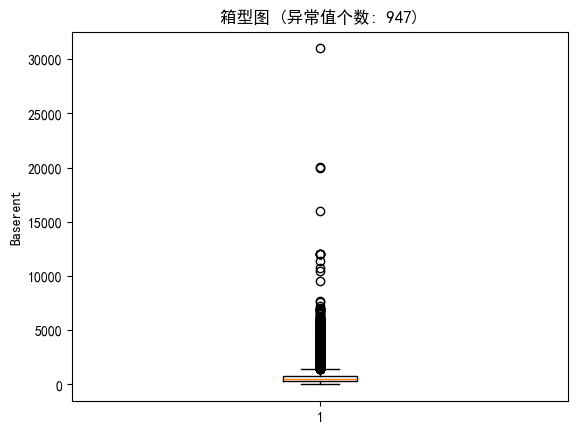

In [26]:
# 图像法来检查合理值范围
plt.boxplot(baserent_f)
# 标出异常值的个数
outliers = baserent_f[(baserent_f < br_lower_bound) | (baserent_f > br_upper_bound)]
num_outliers = len(outliers)

plt.title(f'箱型图 (异常值个数: {num_outliers})')
plt.ylabel('Baserent')

In [27]:
# 重新创建一个用于掩码的布尔值数组(因为对应数组的长度发生变化)，预设所有值位1=keep
mask = np.ones(baserent_f.shape[0], dtype=bool) 

# 给baserent_f设置一个掩码过滤网。 注意：过滤网取名应该是通用的变量名，在后续分析中还要继续添加过滤信息
mask &= (baserent_f >= br_lower_bound) & (baserent_f <= br_upper_bound)

mask[:10]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

Text(0, 0.5, 'Liv Space')

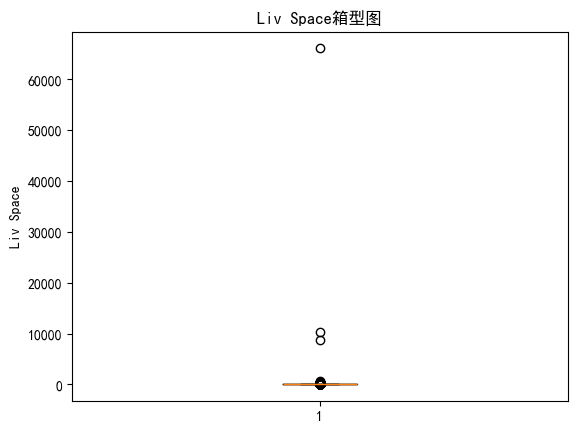

In [28]:
# display liv_space_f for anomalies
# 图像法来检查合理值范围
plt.boxplot(liv_space_f)

plt.title(f'Liv Space箱型图')
plt.ylabel('Liv Space')

In [29]:
# check liv_space_f for anomalies
# 调参一步步接近合理区间
livspace_q0005 = np.quantile(liv_space_f, 0.0005)
livspace_q9995 = np.quantile(liv_space_f, 0.9995)
print(f"Basrent 0.05% Quantile: {livspace_q0005:.2f}, 99.95% Quantile: {livspace_q9995:.2f}")
ls_lower_bound = 12.0
ls_upper_bound = 300.0

Basrent 0.05% Quantile: 12.00, 99.95% Quantile: 300.00


In [30]:
# 继续添加过滤信息
mask &= (liv_space_f >= ls_lower_bound) & (liv_space_f <= ls_upper_bound)

mask[-11:]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

Text(0, 0.5, 'Total Rent')

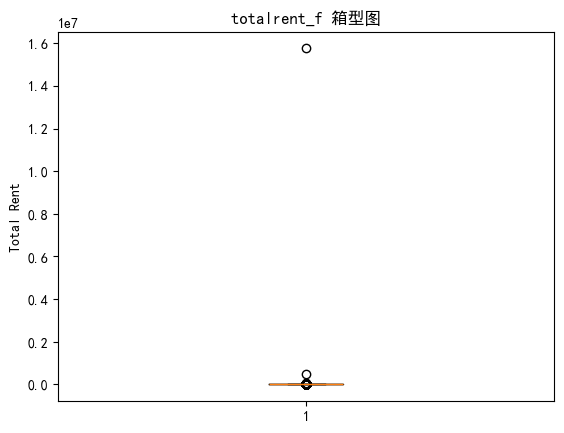

In [31]:
# display liv_space_f for anomalies
# 图像法来检查合理值范围
plt.boxplot(totalrent_f)

plt.title(f'totalrent_f 箱型图')
plt.ylabel('Total Rent')

In [32]:
# check totalrent_f for anomalies
# 调参一步步接近合理区间
totalrent_q005 = np.quantile(totalrent_f, 0.005)
totalrent_q995 = np.quantile(totalrent_f, 0.995)
print(f"Basrent 0.05% Quantile: {totalrent_q005:.2f}, 99.95% Quantile: {totalrent_q995:.2f}")
tr_lower_bound = 230.0
tr_upper_bound = 3500.0

Basrent 0.05% Quantile: 230.00, 99.95% Quantile: 3500.00


In [33]:
# 继续添加过滤信息
mask &= (totalrent_f >= tr_lower_bound) & (totalrent_f <= tr_upper_bound)

mask[:10]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

Text(0, 0.5, 'Year Built')

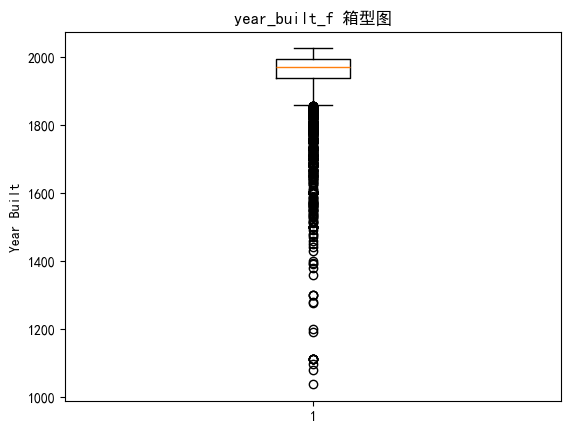

In [34]:
# display year_built_f for anomalies
# 图像法来检查合理值范围
plt.boxplot(year_built_f)

plt.title(f'year_built_f 箱型图')
plt.ylabel('Year Built')

In [35]:
# define limitation of year_built_f for anomalies
yb_lower_bound = 1930.0
yb_upper_bound = 2019.0

In [36]:
# 继续添加过滤信息
mask &= (year_built_f >= yb_lower_bound) & (year_built_f <= yb_upper_bound)

mask[:10]

array([ True,  True,  True, False,  True,  True,  True,  True,  True,
        True])

Text(0, 0.5, 'Room No.')

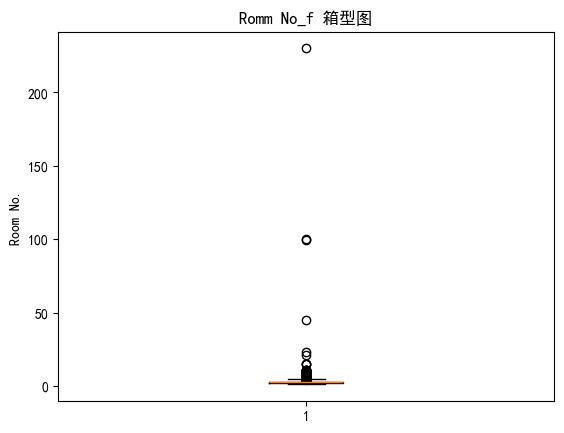

In [37]:
# display liv_space_f for anomalies
# 图像法来检查合理值范围
plt.boxplot(room_no_f)

plt.title(f'Romm No_f 箱型图')
plt.ylabel('Room No.')

In [38]:
# check room_no_f for anomalies
# define limitation of room_no_f for anomalies 
rn_lower_bound = 1.0
rn_upper_bound = 10.0

In [39]:
# 继续添加过滤信息
mask &= (room_no_f >= rn_lower_bound) & (room_no_f <= rn_upper_bound)

mask[:10]

array([ True,  True,  True, False,  True,  True,  True,  True,  True,
        True])

Text(0, 0.5, 'Floor')

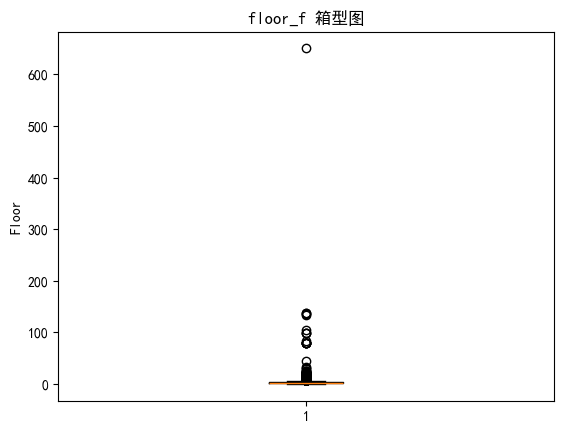

In [40]:
# display floor_f for anomalies
# 图像法来检查合理值范围
plt.boxplot(floor_f)

plt.title(f'floor_f 箱型图')
plt.ylabel('Floor')

In [41]:
# check floor_f for anomalies
# 自定义合理区间
fl_lower_bound = 0
fl_upper_bound = 25

In [42]:
# 继续添加过滤信息
mask &= (floor_f >= fl_lower_bound) & (floor_f <= fl_upper_bound)

mask[:10]

array([ True,  True,  True, False,  True,  True,  True,  True,  True,
        True])

In [43]:
# Wende die Maske auf alle Arrays im Dictionary an
f_arrays = {key: arr[mask] for key, arr in filtered_arrays.items()}

# Ausgabe der gefilterten Arrays
for key, filtered_arr in f_arrays.items():
    print(f"Filtered {key}:\n{filtered_arr}\n")

Filtered date:
['Sep18' 'May19' 'Oct19' ... 'May19' 'Sep18' 'Sep18']

Filtered regio1:
['Nordrhein_Westfalen' 'Sachsen' 'Sachsen_Anhalt' ... 'Sachsen'
 'Niedersachsen' 'Sachsen']

Filtered regio3:
['Emsdetten' 'Bernsdorf' 'Südliche_Neustadt' ... 'Borna' 'Garbsen'
 'Eilenburg']

Filtered geo_krs:
['Steinfurt_Kreis' 'Chemnitz' 'Halle_Saale' ... 'Leipzig_Kreis'
 'Hannover_Kreis' 'Nordsachsen_Kreis']

Filtered geo_plz:
['48282' '09126' '06124' ... '04552' '30827' '04838']

Filtered totalrent:
[578.   449.49 434.82 ... 449.   795.82 700.  ]

Filtered baserent:
[459.   279.74 270.56 ... 329.   578.82 500.  ]

Filtered room_no:
[3. 2. 3. ... 2. 3. 4.]

Filtered floor:
[2. 2. 1. ... 2. 2. 1.]

Filtered liv_space:
[ 75.    60.55  56.25 ...  56.    76.16 100.  ]

Filtered year_built:
[1997. 1930. 1985. ... 1996. 1965. 1995.]



In [44]:
next(iter(f_arrays.values())).shape

(76193,)

### 将清洗和剔除异常值后的数据重新整理成结构化数组集

In [45]:
# rebuild the data from the cleaned dictionary 
date_f= f_arrays['date']
regio1_f = f_arrays['regio1']
regio3_f = f_arrays['regio3']
totalrent_f = f_arrays['totalrent']
baserent_f = f_arrays['baserent']
room_no_f = f_arrays['room_no']
floor_f = f_arrays['floor']
liv_space_f = f_arrays['liv_space']
geo_krs_f = f_arrays['geo_krs']
geo_plz_f = f_arrays['geo_plz']
geo_plz_f = geo_plz_f.astype(str)  # convert to string for consistency
year_built_f = f_arrays['year_built']

## 3. 数据分析和探索，建模  Data Analysis & Data  Mining，Modelling <a id="3"></a>

### 添加有用的信息

- 计算住房面积平均价

In [46]:
price_per_sqm = np.round(baserent_f / liv_space_f, decimals=2)
price_per_sqm[:10]

array([6.12, 4.62, 4.81, 5.84, 9.76, 9.56, 5.  , 5.15, 5.  , 9.55])

In [47]:
# check the new calculated price_per_sqm
m2price_summary = pds.describe_array(price_per_sqm)
print("Array statistical overview: \n")
for key, value in m2price_summary.items():
    print(f"{key}:  {value}")

Array statistical overview: 

Size:  76193
dtype:  float64
Shape:  (76193,)
Memory_usage:  609544
NaN_count:  0
finite_count:  76193
Mean:  8.632825456406756
Median:  7.32
Min:  1.96
Max:  75.88
Range:  73.92
Std:  4.468021185347678
Var:  19.963213312715666
Skewness:  2.4951297160126304
Kurtosis:  14.144769623081146


### 查询全德国房租信息

数据处理：
- 提问：德国各个州的房租情况如何？ 
  - 解决方案：统计德国州数据，需要按州分类
- 提问：可否计算各州平均水平？ 
  - 解决方案：统计各州房租的平均值/每平米房租的平均值
- 提问: 可否给个排行榜？
  - 将房租均值按高低排序，要求对应的州也要按同样次序排序
- 提问：巴符州租金有何变化？
  - 解决方案： 看巴符州的历史数据

In [48]:
# 区域分析
unique_regions, region_counts = np.unique(regio1_f,return_counts = True)
print(unique_regions)
#unique_regions
region1_br_mean = np.array([baserent_f[regio1_f == r ].mean().astype(int) for r in unique_regions])
print(len(region1_br_mean), len(unique_regions), len(region_counts))


# 创建描述数组排序的索引
sorted_indices = np.argsort(region1_br_mean)[::-1]  # 从大到小排序

# 使用索引为2个数组（字符串和数值数值）排序 
sorted_regio1 = unique_regions[sorted_indices]
sorted_br = region1_br_mean[sorted_indices]

# 输出排序
for description, value in zip(sorted_regio1, sorted_br):
    print(f"{description}: {value}")

['Baden_Württemberg' 'Bayern' 'Berlin' 'Brandenburg' 'Bremen' 'Hamburg'
 'Hessen' 'Mecklenburg_Vorpommern' 'Niedersachsen' 'Nordrhein_Westfalen'
 'Rheinland_Pfalz' 'Saarland' 'Sachsen' 'Sachsen_Anhalt'
 'Schleswig_Holstein' 'Thüringen']
16 16 16
Hamburg: 1059
Berlin: 997
Bayern: 987
Baden_Württemberg: 955
Hessen: 950
Rheinland_Pfalz: 720
Schleswig_Holstein: 633
Bremen: 606
Niedersachsen: 593
Nordrhein_Westfalen: 585
Saarland: 547
Brandenburg: 469
Sachsen: 431
Mecklenburg_Vorpommern: 383
Thüringen: 353
Sachsen_Anhalt: 341


### 关于datetime format的一点介绍

GTP4-o: Hier sind einige der häufigsten Formatierungsoptionen:

    %Y: Vierstellige Jahreszahl (z.B. 2023)
    %y: Zweistellige Jahreszahl (z.B. 23 für 2023)
    %m: Monat als Zahl (01 bis 12)
    %b: Abgekürzter Monatsname (z.B. Jan, Feb, Mär, Apr, Mai, Jun, Jul, Aug, Sep, Okt, Nov, Dez)
    %B: Vollständiger Monatsname (z.B. Januar, Februar, ...)
    %d: Tag des Monats (01 bis 31)
    %H: Stunde im 24-Stunden-Format (00 bis 23)
    %I: Stunde im 12-Stunden-Format (01 bis 12)
    %M: Minuten (00 bis 59)
    %S: Sekunden (00 bis 59)
    %A: Vollständiger Wochentag (z.B. Montag, Dienstag, ...)
    %a: Abgekürzter Wochentag (z.B. Mo, Di, ...)

Bedeutung von format='%d-%b%y':

    %d: Der Tag des Monats als zweistellige Zahl (01 bis 31).
    %b: Der abgekürzte Monatsname (z.B. Jan, Feb, Mär, ...).
    %y: Die zweistellige Jahreszahl (z.B. 23 für 2023).

Beispiel

Wenn du das Format '%d-%b%y' verwendest, könnte ein Datum wie 01-Sep18 interpretiert werden als:

    Tag: 01
    Monat: September (Sep)
    Jahr: 2018 (18)


In [49]:
print(date_f[:10])
# convert data_f values into Pandas Datetime-Array
date_strings = [f'01-{date}' for date in date_f]  # z.B. '01-Sep18'
datetime_array = pd.to_datetime(date_strings, format='%d-%b%y')  # definition of input data format 
datetime_array[:10]

['Sep18' 'May19' 'Oct19' 'May19' 'Sep18' 'Oct19' 'Oct19' 'Oct19' 'Oct19'
 'May19']


DatetimeIndex(['2018-09-01', '2019-05-01', '2019-10-01', '2019-05-01',
               '2018-09-01', '2019-10-01', '2019-10-01', '2019-10-01',
               '2019-10-01', '2019-05-01'],
              dtype='datetime64[ns]', freq=None)

<Axes: xlabel='None', ylabel='None'>

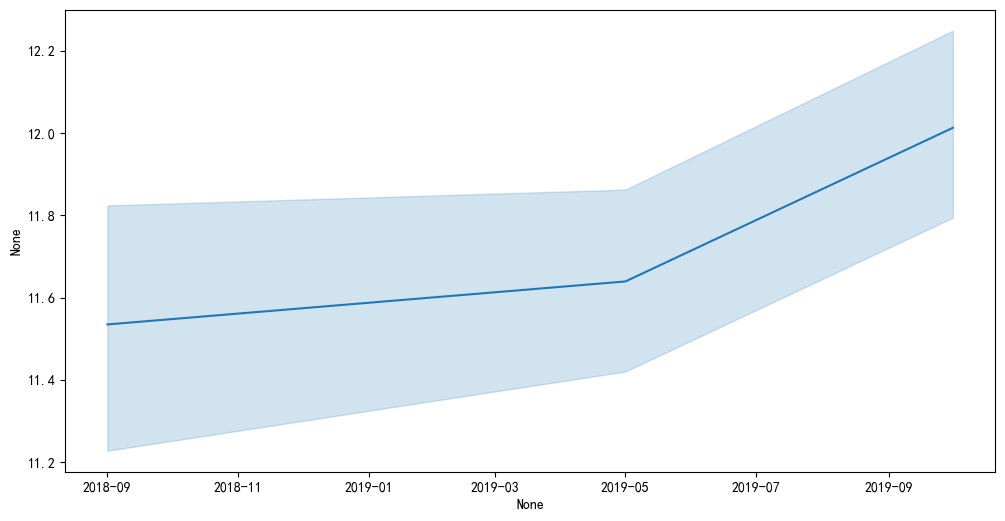

In [50]:
import seaborn as sns
fig = plt.figure(figsize=(12, 6))
sns.lineplot(x=pd.Series(datetime_array), y=pd.Series(price_per_sqm)[regio1_f == 'Baden_Württemberg']) 

Text(0.5, 1.0, 'Violin Plot für Preis pro Quadratmeter in Baden-Württemberg')

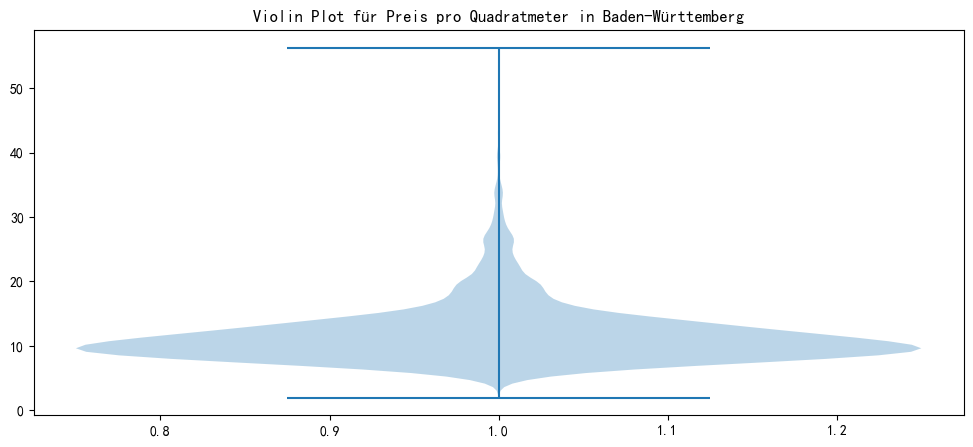

In [51]:
# plot a violin plot for price_per_sqm
fig = plt.figure(figsize=(12, 5))
plt.violinplot(pd.Series(price_per_sqm)['Baden_Württemberg' == regio1_f])
plt.title('Violin Plot für Preis pro Quadratmeter in Baden-Württemberg')

### 相关系数

np.corrcoef 可以处理多个数组，只需将它们组合成一个二维数组即可。这样就可以轻松计算多个变量之间的相关系数。
- 将这些数组组合成一个二维数组: 
    - data = np.array([array1, array2, array3])
- 计算相关系数矩阵:
    - correlation_matrix = np.corrcoef(data)


In [52]:
# create a set of np arrays for corr ananlysis
corr_arrays = np.array([
    baserent_f,liv_space_f,room_no_f,floor_f,year_built_f,totalrent_f,price_per_sqm
])
corr_matrix = np.corrcoef(corr_arrays)    

<Axes: >

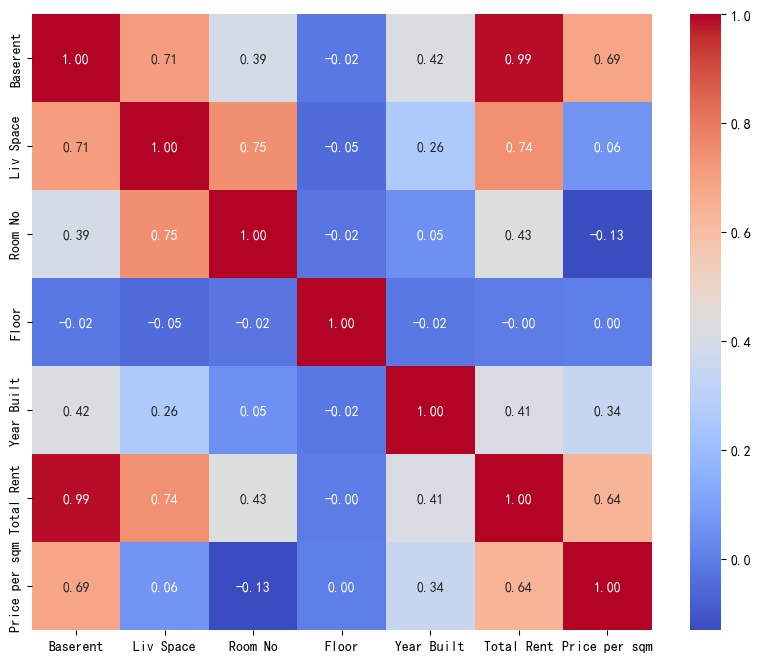

In [53]:
# visulaize the correlation matrix using heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=ax,
            xticklabels=['Baserent', 'Liv Space', 'Room No', 'Floor', 'Year Built', 'Total Rent', 'Price per sqm'],
            yticklabels=['Baserent', 'Liv Space', 'Room No', 'Floor', 'Year Built', 'Total Rent', 'Price per sqm'])


<Axes: >

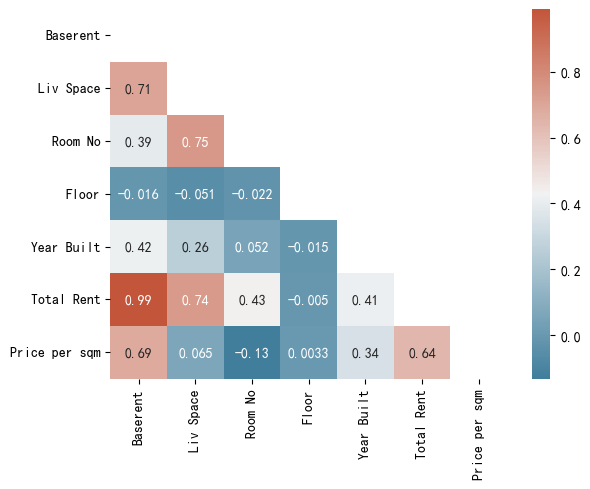

In [54]:
# Die Heatmap zeigt die Werte der Korrelationsmatrix an. 
# Die Werte werden in den Zellen angezeigt (annot=True).
# Eine divergierende Farbpalette von Blau nach Gelb wird verwendet, um positive und negative Korrelationen visuell zu unterscheiden.
# Die obere Hälfte der Heatmap wird maskiert, sodass nur die untere Hälfte der Korrelationsmatrix angezeigt wird, um Redundanz zu vermeiden.
#
sns.heatmap(corr_matrix, annot=True, cmap=sns.diverging_palette(230, 20, as_cmap=True), mask=np.triu(np.ones_like(corr_matrix, dtype=bool)),
            xticklabels=['Baserent', 'Liv Space', 'Room No', 'Floor', 'Year Built', 'Total Rent', 'Price per sqm'],
            yticklabels=['Baserent', 'Liv Space', 'Room No', 'Floor', 'Year Built', 'Total Rent', 'Price per sqm'])

## 建立自己的分析模型

从相关系数以及热图图像里可以找出最大相关的对应项。我们就可以举例建立自己的分析模型。

模型1： baseRent & livingSpace相关模型： 
- 相关性假设：租房越大，租金应该越贵。

模型2：  price_per_sqm & livingSpace不相关模型：
- 疑问：为什么面积均价和住房面积几乎无关，虽然面积均价和冷租强相关？Maybe it is because m2_price decreases from a certain apartment size?


Text(0, 0.5, 'Living Space')

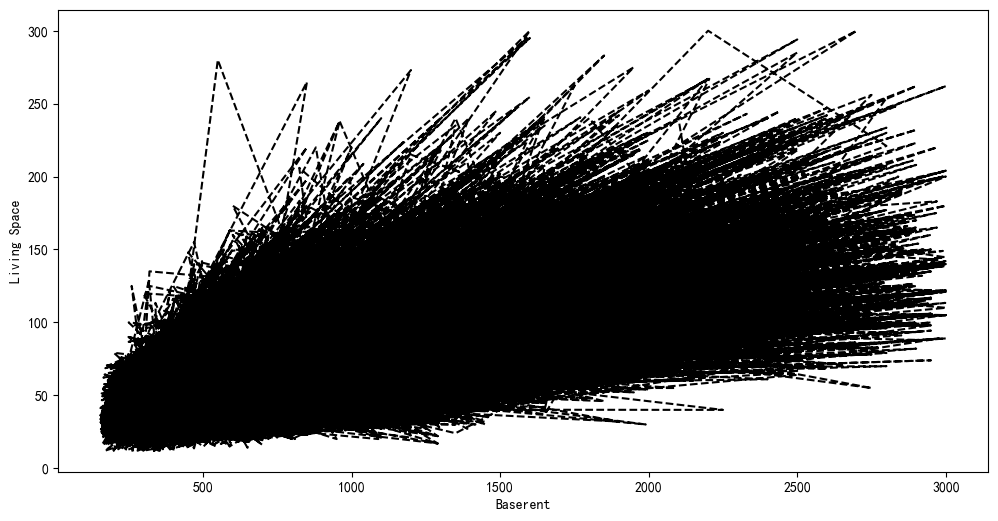

In [69]:
# line plot
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)
ax.plot(baserent_f,liv_space_f,  'k--', label='Price per sqm')
ax.set_xlabel('Baserent')
ax.set_ylabel('Living Space')   

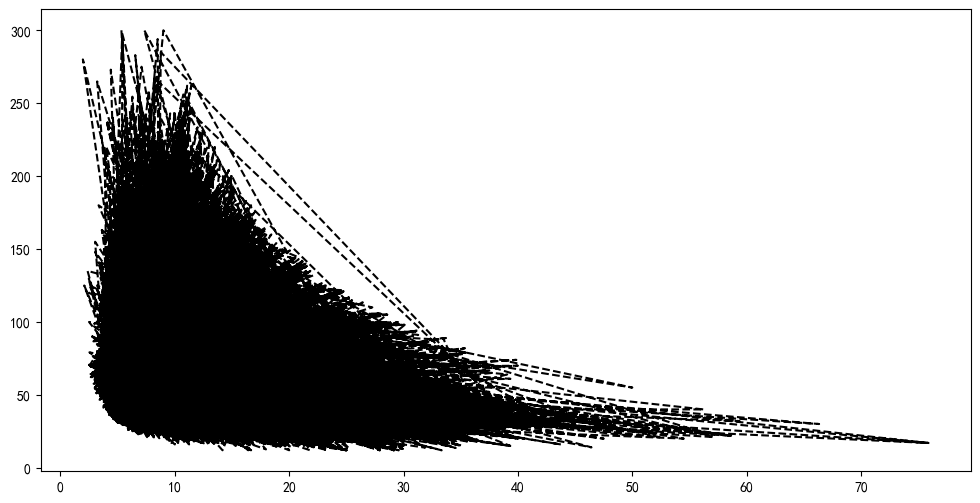

In [68]:
# line plot
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)
ax.plot(price_per_sqm,liv_space_f,  'k--')

<Axes: >

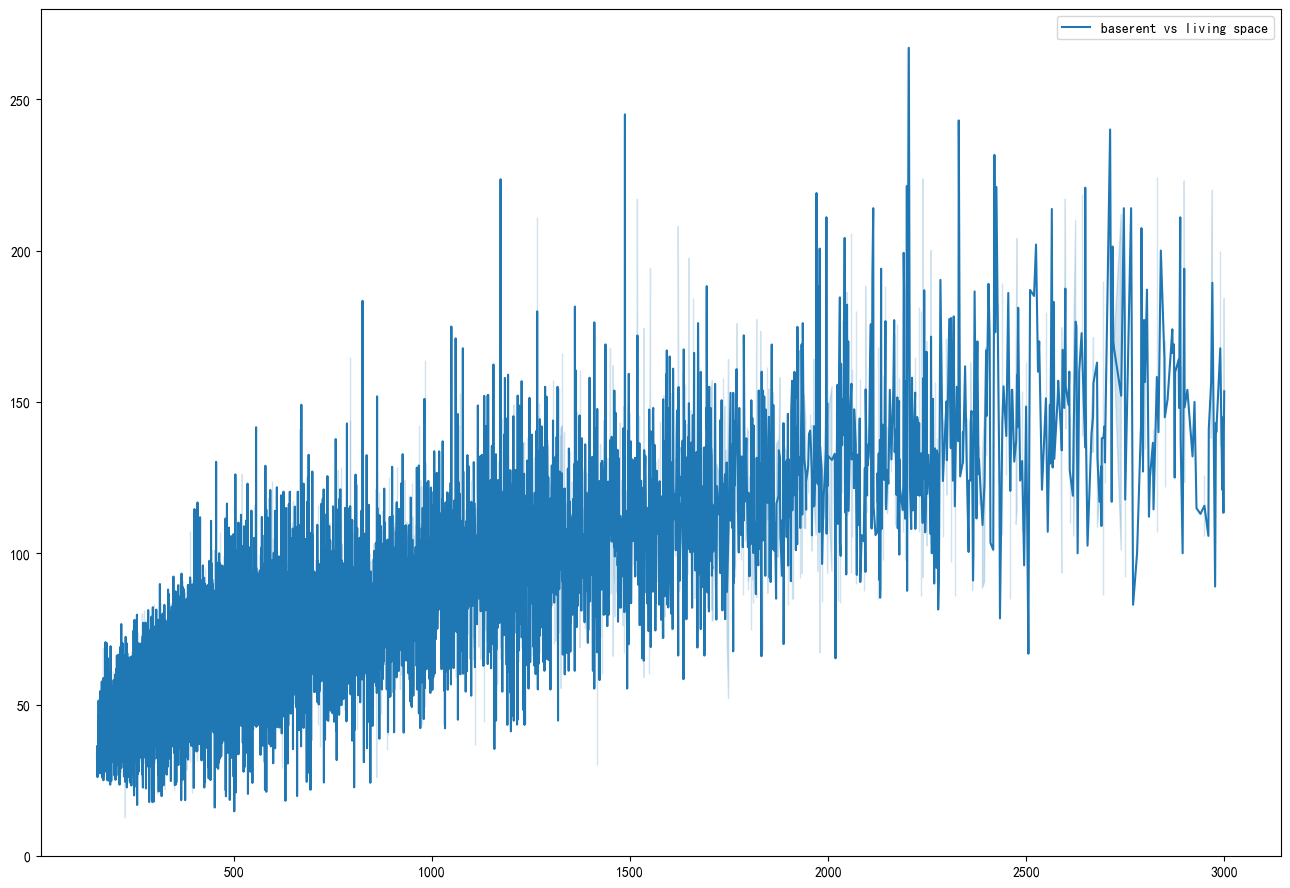

In [70]:
# try seaborn plot
sns.lineplot(x=baserent_f, y=liv_space_f, label='baserent vs living space')

<Axes: >

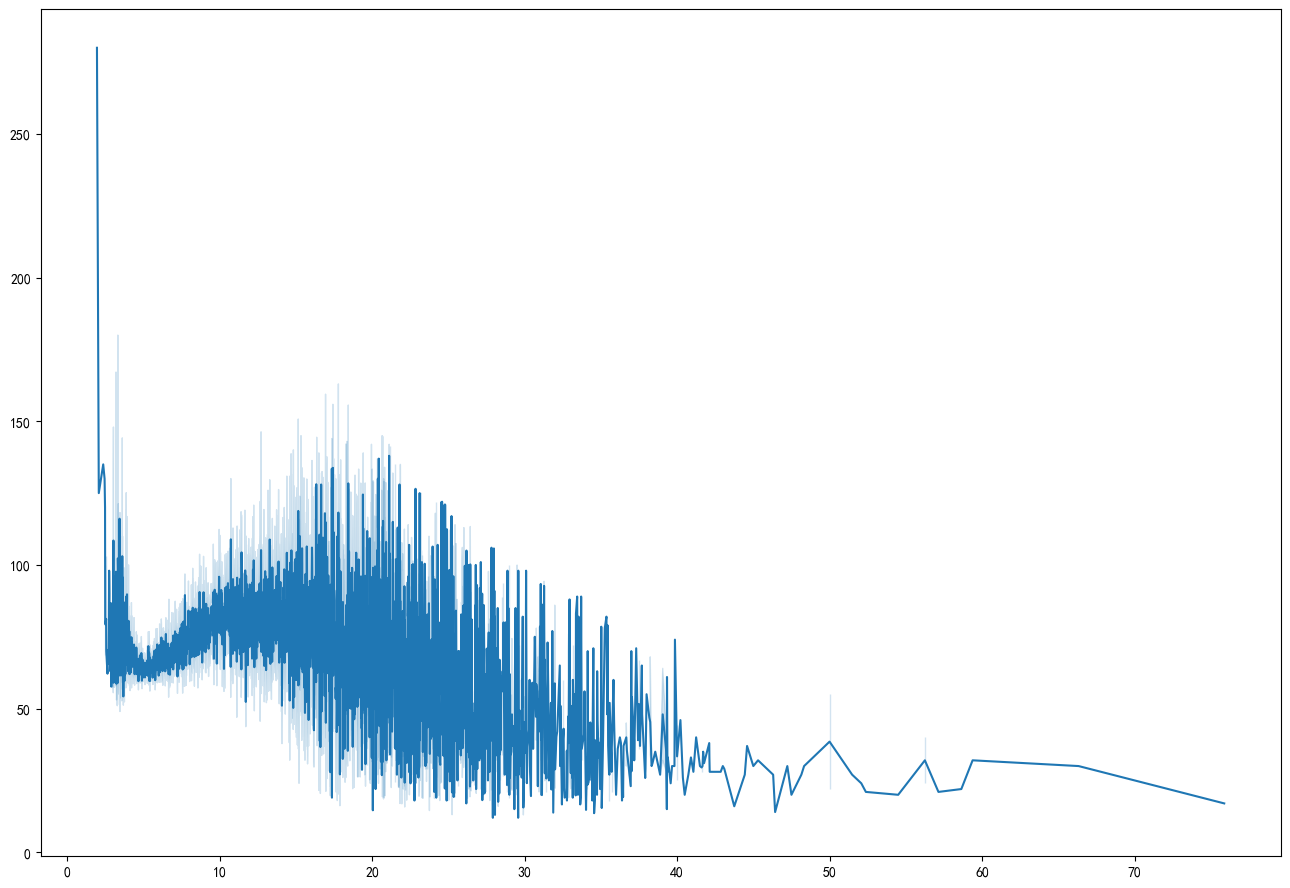

In [65]:
# try seaborn 
sns.lineplot(x=price_per_sqm,y=liv_space_f)

### Use folium 

to create a use defined map, all you need to do is set a map by giving it a location latitude and longitude, as well as zoom

you can download the pLZ geodata (as shapefile) of gemany from the open source
https://www.suche-postleitzahl.org/downloads

In [56]:
import folium as folium

# Koordinaten von Stuttgart
stuttgart_coords = [48.7758, 9.1829]
"""
# Koordinaten von Ludwigsburg und Böblingen
ludwigsburg_coords = [48.8984, 9.2016]
boeblingen_coords = [48.6842, 9.0052]
"""

# Erstellen einer Karte
map_stuttgart = folium.Map(location=stuttgart_coords, zoom_start=12)

# Karte speichern
map_stuttgart.save("stuttgart_map.html")
# Füge Marker für jede Immobilie hinzu
# Karte anzeigen
map_stuttgart

In [57]:
# Koordinaten für Ludwigsburg
ludwigsburg_coords = [48.8984, 9.2016]

# Erstellen einer Karte für Ludwigsburg
map_ludwigsburg = folium.Map(location=ludwigsburg_coords, zoom_start=13)

# Koordinaten für das Polygon (Beispielkoordinaten)
polygon_coords = [
    [48.8950, 9.2000],
    [48.8950, 9.2050],
    [48.8970, 9.2050],
    [48.8970, 9.2000],
    [48.8950, 9.2000]  # Letzter Punkt muss der erste Punkt sein, um das Polygon zu schließen
]

# Hinzufügen des Polygons zur Karte
folium.Polygon(locations=polygon_coords, color='blue', fill=True, fill_opacity=0.5).add_to(map_ludwigsburg)

# Karte anzeigen
map_ludwigsburg

In [58]:
from folium.plugins import HeatMap

# Erstellen einer Karte für Ludwigsburg
ludwigsburg_coords = [48.8984, 9.2016]
map_ludwigsburg = folium.Map(location=ludwigsburg_coords, zoom_start=13)

# Fiktive Daten für die Heatmap (Koordinaten und Einwohnerzahlen)
# Format: [ [latitude, longitude, value], ... ]
data = [
    [48.8950, 9.2000, 100],  # Beispielkoordinaten mit Einwohnerzahl
    [48.8960, 9.2020, 200],
    [48.8970, 9.2030, 150],
    [48.8980, 9.2040, 300],
    [48.8990, 9.2050, 250],
]

# Hinzufügen der Heatmap zur Karte
HeatMap(data).add_to(map_ludwigsburg)

# Karte anzeigen
map_ludwigsburg

In [59]:
import geopandas as gpd

# read geojson file
ger_df = gpd.read_file('./data/ger_df.geojson', dtype={'plz': str})
ger_df.head()

,plz,ort,bundesland,einwohner,Mean Price,geometry
0,64760,Oberzent,Hessen,10503,483,"POLYGON ((8.87295 49.60682, 8.87355 49.60679, ..."
1,35647,Waldsolms,Hessen,4855,670,"MULTIPOLYGON (((8.42331 50.45239, 8.4239 50.45..."
2,31195,Lamspringe,Niedersachsen,5876,417,"POLYGON ((9.89081 51.96869, 9.8911 51.96875, 9..."
3,31084,Freden (Leine),Niedersachsen,4892,578,"MULTIPOLYGON (((9.84891 51.93198, 9.85289 51.9..."
4,27639,Wurster Nordseeküste,Niedersachsen,17093,445,"POLYGON ((8.4829 53.68783, 8.48314 53.68867, 8..."


In [60]:
# Get lat and lng of Germany's main cities. 
top_cities = {
    'Berlin': (13.404954, 52.520008), 
    'Cologne': (6.953101, 50.935173),
    'Düsseldorf': (6.782048, 51.227144),
    'Frankfurt am Main': (8.682127, 50.110924),
    'Hamburg': (9.993682, 53.551086),
    'Leipzig': (12.387772, 51.343479),
    'Munich': (11.576124, 48.137154),
    'Dortmund': (7.468554, 51.513400),
    'Stuttgart': (9.181332, 48.777128),
    'Nuremberg': (11.077438, 49.449820),
    'Hannover': (9.73322, 52.37052)
}

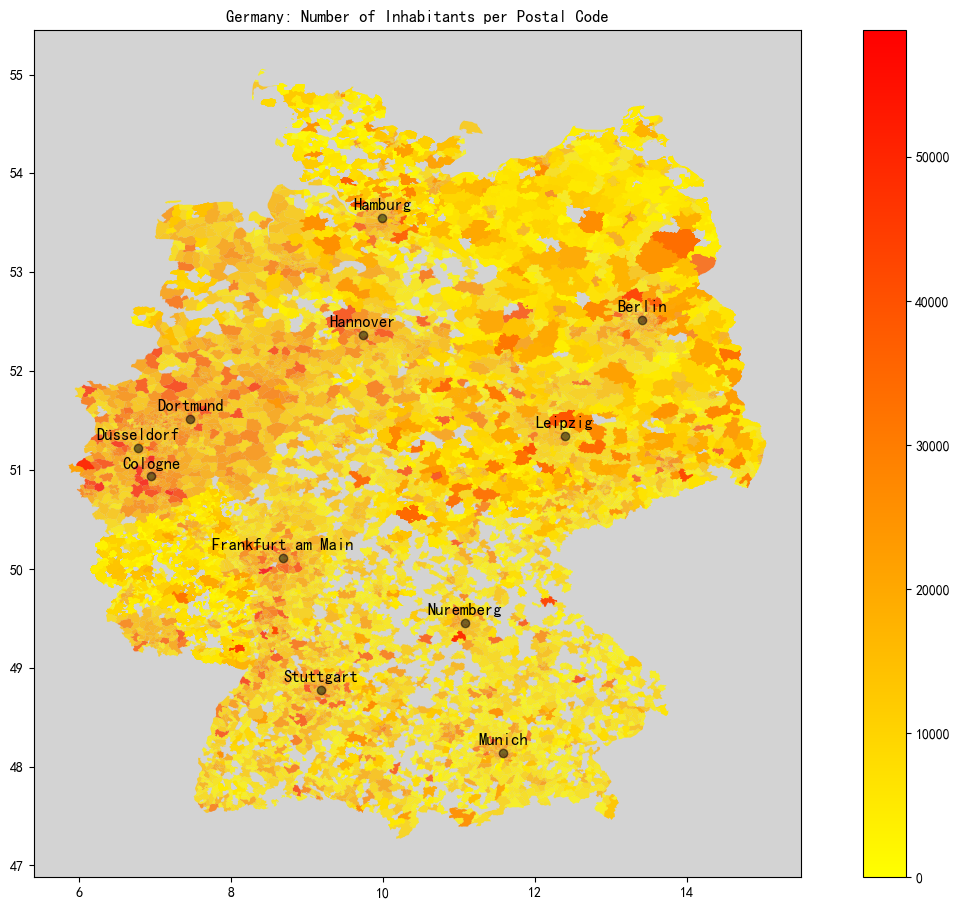

In [61]:
# Plot the map
plt.rcParams['figure.figsize'] = [16, 11]

fig, ax = plt.subplots()

ger_df.plot(
    ax=ax, 
    column='einwohner', 
    categorical=False, 
    legend=True, 
    cmap='autumn_r',
    alpha=0.8
)

for city in top_cities.keys():

    ax.text(
        x=top_cities[city][0], 
        y=top_cities[city][1] + 0.08, 
        s=city, 
        fontsize=12,
        ha='center', 
    )

    ax.plot(
        top_cities[city][0], 
        top_cities[city][1], 
        marker='o',
        c='black', 
        alpha=0.5
    )
    
ax.set(
    title='Germany: Number of Inhabitants per Postal Code', 
    aspect=1.3, 
    facecolor='lightgray'
);

In [62]:
folium.GeoJson(ger_df)

In [63]:
# Focus on one city is possible through a filter

def city_map(city):
    q = 'ort == "' + city + '"'
    city_df = ger_df.query(q)

    fig, ax = plt.subplots()

    city_df.plot(
        ax=ax, 
        column='einwohner', 
        categorical=False, 
        legend=True, 
        cmap='autumn_r',
    )

    ax.set(
        title= city + ': Number of Inhabitants per Postal Code', 
        aspect=1.3, 
        facecolor='lightgray'
    )


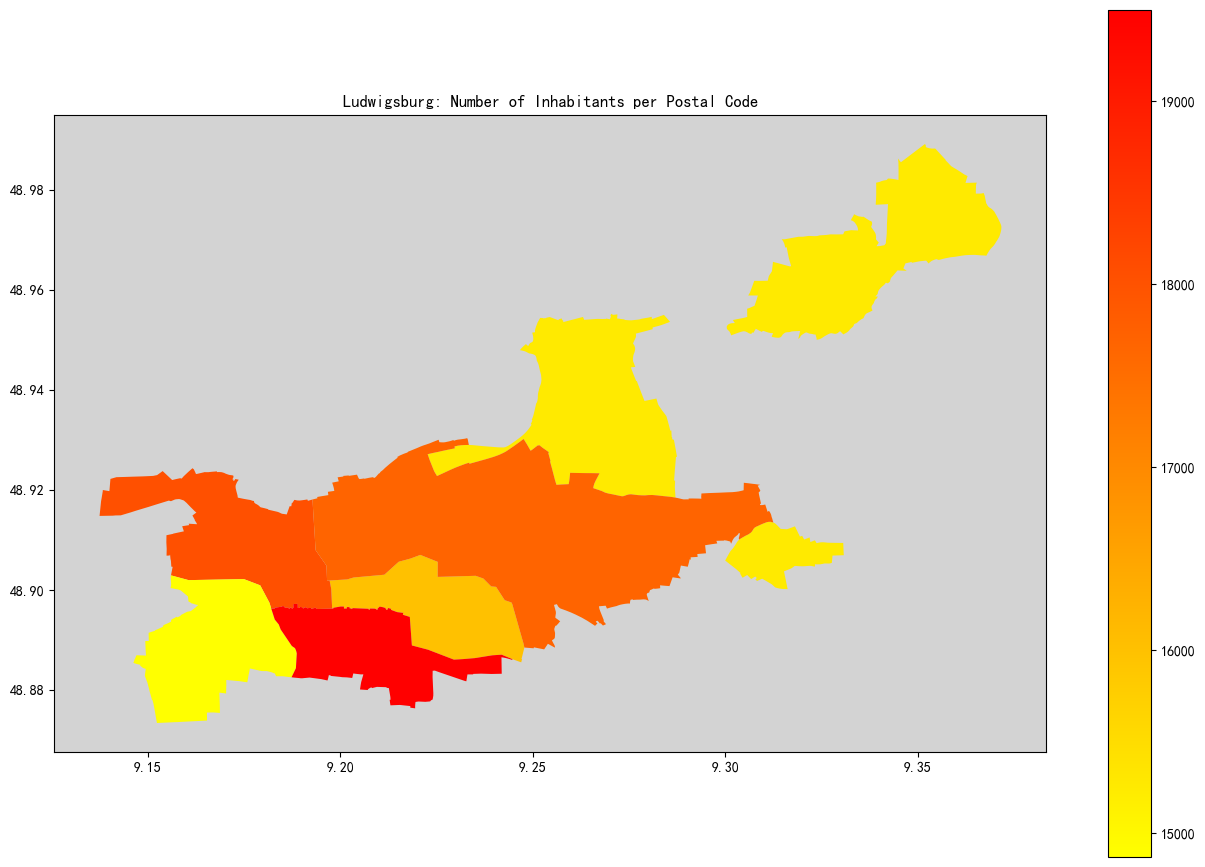

In [64]:
city_map("Ludwigsburg")

## 4. 模型评估 Model Evaluation <a id="4"></a> 

## 5. 业务理解/知识深化和提升  <a id="5"></a> 